In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Daksh_Gururkul_IITG_May_2025/14_Bayes_Classifier/hearing_test.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             5000 non-null   float64
 1   physical_score  5000 non-null   float64
 2   test_result     5000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 117.3 KB


In [4]:
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


# Exploratory Data Analysis

In [5]:
df['test_result'].value_counts()

,count
test_result,
1,3000
0,2000


/tmp/ipython-input-1191728725.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='test_result',y='age',data=df,palette='viridis')


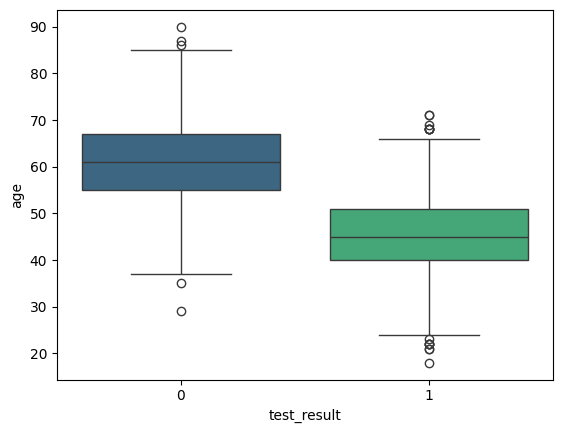

In [6]:
sns.boxplot(x='test_result',y='age',data=df,palette='viridis')
plt.show()

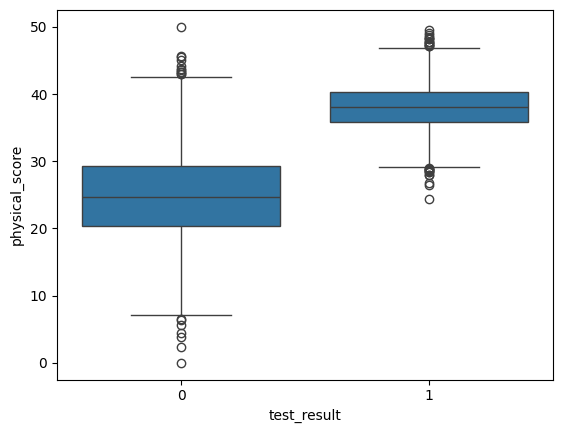

In [7]:
sns.boxplot(x='test_result',y='physical_score',data=df)
plt.show()

<Axes: xlabel='age', ylabel='physical_score'>

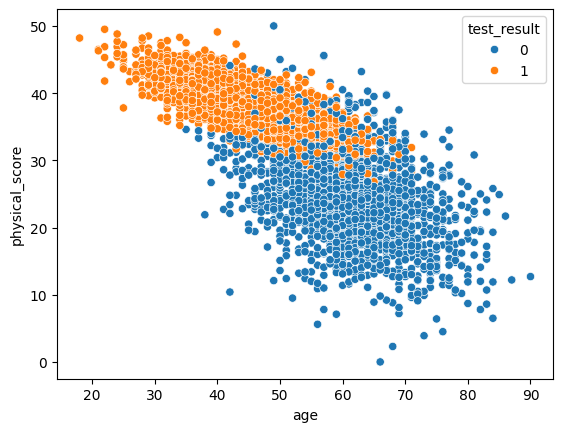

In [8]:
sns.scatterplot(x='age',y='physical_score',data=df,hue='test_result')

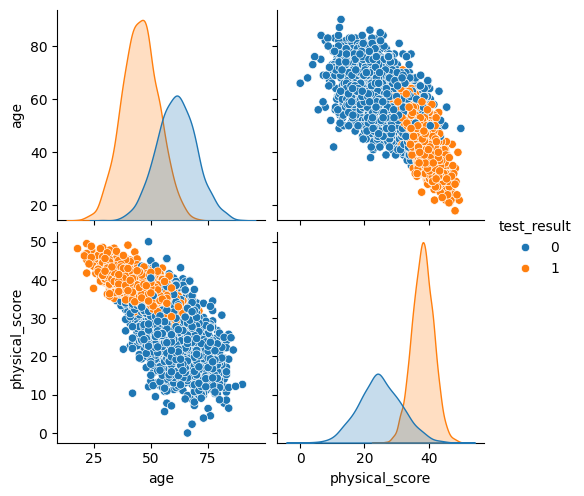

In [9]:
sns.pairplot(df,hue='test_result')

In [10]:
df.corr()

,age,physical_score,test_result
age,1.000000,-0.782146,-0.683171
physical_score,-0.782146,1.000000,0.792716
test_result,-0.683171,0.792716,1.000000


<Axes: xlabel='physical_score', ylabel='test_result'>

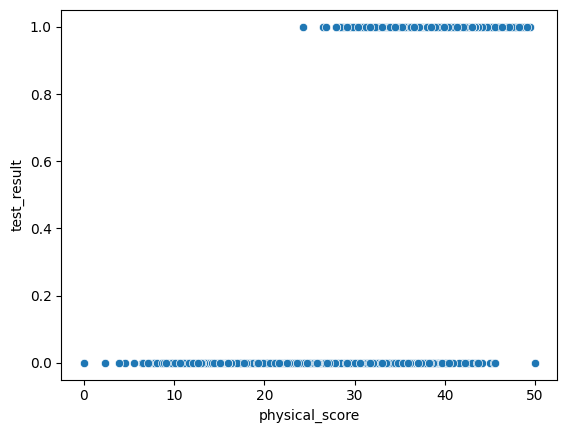

In [11]:
sns.scatterplot(x='physical_score',data=df,y='test_result')

# Train | Test Split

In [12]:
X = df.drop('test_result',axis=1)
y = df['test_result']

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=51)

In [15]:
sc = StandardScaler()

In [16]:
sc_X_train = sc.fit_transform(X_train)

sc_X_test = sc.transform(X_test)

In [17]:
from sklearn.naive_bayes import GaussianNB

#from sklearn.linear_model import LogisticRegression

In [18]:
nb_model = GaussianNB()

#nb_model = LogisticRegression()

In [19]:
nb_model.fit(sc_X_train,y_train)

GaussianNB()

In [20]:
y_test

,test_result
3936,1
2750,1
3652,1
145,1
4319,1
...,...
4723,1
894,0
99,0
648,0


In [26]:
y_pred = nb_model.predict(sc_X_test)

In [36]:
y_proba = nb_model.predict_proba(sc_X_test)

In [27]:
#nb_model.predict_proba(sc_X_test).sum(axis=1)

In [24]:
nb_model.predict_proba(sc.transform([[50,32],[54,32],[90,12]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[3.09603273e-01, 6.90396727e-01],
       [5.23695698e-01, 4.76304302e-01],
       [1.00000000e+00, 1.34197326e-16]])

# Model Performance

In [43]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

In [28]:
accuracy_score(y_test,y_pred)

0.913

In [29]:
confusion_matrix(y_test,y_pred)

array([[359,  49],
       [ 38, 554]])

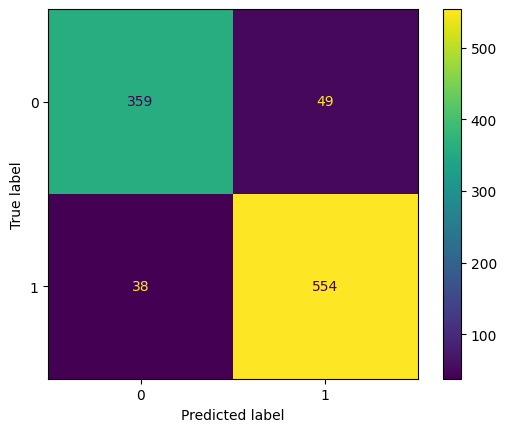

In [31]:
cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm).plot()

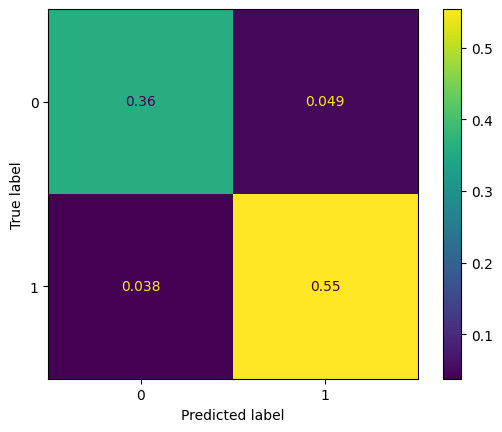

In [32]:
cm = confusion_matrix(y_test,y_pred,normalize='all')
ConfusionMatrixDisplay(cm).plot()

In [34]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89       408
           1       0.92      0.94      0.93       592

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000



# Evaluating Curves and AUC

In [35]:
from sklearn import metrics

In [40]:
#help(metrics.roc_curve)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


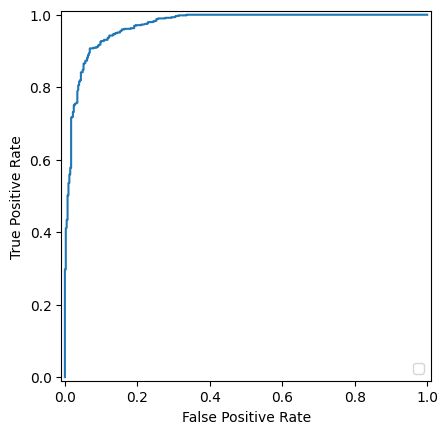

In [42]:
y_score = y_proba[:,1]

fpr, tpr, thresholds = metrics.roc_curve(y_test,y_score)

RocCurveDisplay(fpr=fpr,tpr=tpr).plot()

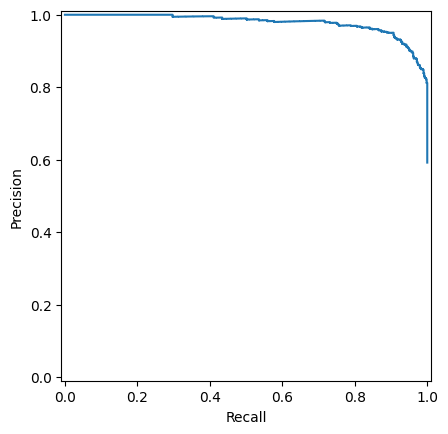

In [44]:
precision, recall, thresholds = metrics.precision_recall_curve(y_test,y_score)

PrecisionRecallDisplay(precision=precision,recall=recall).plot()

# Chebyshev Classifier

In [49]:
class ChebyshevClassifier:

  def __init__(self,agg='mean',k_threshold=None,eps=.000001):
    self.agg = agg
    self.k_threshold = k_threshold
    self.eps = eps
    self.class_stats = {}
    self.classes = None

  def fit(self,X,y):
    X,y = np.asarray(X), np.asarray(y)
    self.classes_ = np.unique(y)

    for c in self.classes_:
      Xc = X[y==c]
      mu = Xc.mean(axis=0)
      var = Xc.var(axis=0)
      var[var < self.eps] = self.eps
      sigma = np.sqrt(var)
      self.class_stats[c] = {'mu':mu, 'sigma':sigma}
    return self

  def _score_sample(self,x):
    scores = {}
    for c,stats in self.class_stats.items():
      z = np.abs(x - stats['mu'])/stats['sigma']
      agg_z = z.mean() if self.agg == 'mean' else z.max()
      scores[c] = agg_z
    return scores

  def predict(self,X):
    preds = []
    outlier_flags = []

    for x in X:
      scores = self._score_sample(x)
      best_c = min(scores, key=scores.get)

      preds.append(best_c)

      best_z = scores[best_c]
      if (self.k_threshold is not None) and (best_z > self.k_threshold):
        outlier_flags.append(1)
      else:
        outlier_flags.append(0)

    return np.array(preds), np.array(outlier_flags)


In [50]:
cb = ChebyshevClassifier()

In [51]:
cb.fit(sc_X_train,y_train)

In [53]:
y_pred_cb, outliers = cb.predict(sc_X_test)

In [54]:
y_pred_cb

array([1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1,

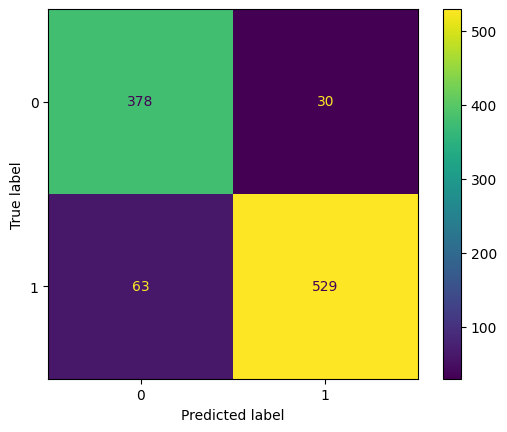

In [55]:
cm = confusion_matrix(y_test,y_pred_cb)
ConfusionMatrixDisplay(cm).plot()